In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
global_data = pd.read_csv("global air pollution dataset.csv")

In [20]:
print(global_data.head())

              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2               Italy   Priolo Gargallo         66     Moderate             1   
3              Poland         Przasnysz         34         Good             1   
4              France          Punaauia         22         Good             0   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good               39               Good              2   
3            Good               34               Good              0   
4            Good               22               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Category  
0             Good     

In [21]:
print(global_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB
None


In [22]:
print(global_data.columns)

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')


In [23]:
print(global_data.columns.tolist())

['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


In [24]:
X = global_data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']]
y = global_data['AQI Value']


In [25]:
X = global_data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']]
y = global_data['AQI Category']


In [26]:
# Select only numeric columns
numeric_cols = global_data.select_dtypes(include=['float64','int64']).columns

# Fill missing values in numeric columns with their mean
global_data[numeric_cols] = global_data[numeric_cols].fillna(global_data[numeric_cols].mean())

In [13]:
for col in global_data.columns:
    if global_data[col].dtype in ['float64','int64']:
        global_data[col] = global_data[col].fillna(global_data[col].mean())
    else:
        global_data[col] = global_data[col].fillna(global_data[col].mode()[0])

In [15]:
global_data = global_data.dropna()


In [27]:
X = global_data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']]
y = global_data['AQI Value']   # numeric target


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [38]:
y_pred = model.predict(X_test)

In [40]:
X = global_data[['CO AQI Value','Ozone AQI Value','NO2 AQI Value','PM2.5 AQI Value']]
y = global_data['AQI Category']   # categorical target

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.998934583422118
                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      2014
                     Hazardous       0.98      0.95      0.96        42
                      Moderate       1.00      1.00      1.00      1837
                     Unhealthy       1.00      1.00      1.00       419
Unhealthy for Sensitive Groups       1.00      1.00      1.00       321
                Very Unhealthy       0.97      0.97      0.97        60

                      accuracy                           1.00      4693
                     macro avg       0.99      0.99      0.99      4693
                  weighted avg       1.00      1.00      1.00      4693



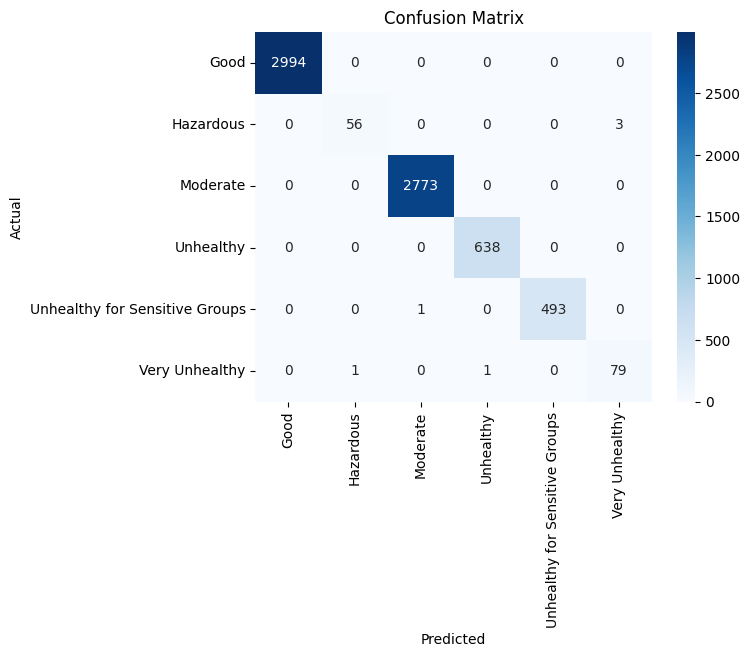

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [20]:

import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())


Cross-validation scores: [0.9987215  0.99957383 0.99850842 0.99914749 0.99978687]
Mean accuracy: 0.999147621323518


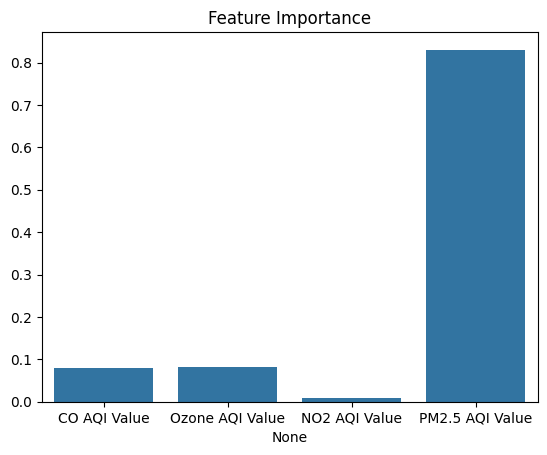

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns
importances = model.feature_importances_
sns.barplot(x=X.columns, y=importances)
plt.title("Feature Importance")
plt.show()


In [41]:
import tkinter as tk
from tkinter import messagebox
import time
import datetime

def update_clock():
    """Update the live clock every second."""
    now = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    clock_label.config(text=now)
    root.after(1000, update_clock)

def predict_aqi():
    try:
        co = float(entry_co.get())
        ozone = float(entry_ozone.get())
        no2 = float(entry_no2.get())
        pm25 = float(entry_pm25.get())

        # Example AQI calculation (replace with your model if needed)
        aqi_value = (co + ozone + no2 + pm25) / 4

        # Map AQI value to category, safety message, and background color
        if aqi_value <= 50:
            prediction = "Good"
            safety_msg = "✅ It is safe to go outside."
            bg_color = "#90ee90"  # light green
            icon = "✅"
        elif aqi_value <= 100:
            prediction = "Moderate"
            safety_msg = "⚠️ Air quality is acceptable, but sensitive individuals should take care."
            bg_color = "#ffff99"  # light yellow
            icon = "⚠️"
        elif aqi_value <= 150:
            prediction = "Unhealthy for Sensitive Groups"
            safety_msg = "⚠️ Sensitive groups should limit outdoor exposure."
            bg_color = "#ffcc99"  # orange
            icon = "⚠️"
        elif aqi_value <= 200:
            prediction = "Unhealthy"
            safety_msg = "❌ Not safe to go outside. Avoid outdoor activities."
            bg_color = "#ff6666"  # red
            icon = "❌"
        elif aqi_value <= 300:
            prediction = "Very Unhealthy"
            safety_msg = "❌ Very unsafe. Stay indoors and wear a mask if necessary."
            bg_color = "#9900cc"  # purple
            icon = "❌"
        else:
            prediction = "Hazardous"
            safety_msg = "☠️ Extremely unsafe. Stay indoors and avoid exposure."
            bg_color = "#660000"  # dark maroon
            icon = "☠️"

        # Progress bar animation
        progress_label.config(text="Calculating prediction...")
        for i in range(0, 101, 10):
            progress_bar.config(width=i*3)
            root.update()
            time.sleep(0.05)
        progress_label.config(text="Prediction complete!")

        # Animate result text
        result_label.config(text="", fg="blue")
        for char in f"{icon} Predicted AQI Category: {prediction}":
            current_text = result_label.cget("text")
            result_label.config(text=current_text + char)
            root.update()
            time.sleep(0.03)

        # Change background color dynamically
        root.configure(bg=bg_color)
        frame.configure(bg=bg_color)
        title_label.configure(bg=bg_color)
        footer_label.configure(bg=bg_color)
        guidelines_label.configure(bg=bg_color)
        clock_label.configure(bg=bg_color)

        # Show safety message
        messagebox.showinfo("Safety Advice", safety_msg)

        # Show warning message if AQI is dangerous
        if prediction in ["Unhealthy", "Very Unhealthy", "Hazardous"]:
            messagebox.showwarning("Air Quality Alert",
                       f"⚠️ Warning: The air quality is {prediction}.\n"
                       "Avoid outdoor activities and wear a mask")

    except ValueError:
        messagebox.showerror("Error", "Please enter valid numeric values.")


# Tkinter window
root = tk.Tk()
root.title("🌍 Global AQI Prediction Dashboard")
root.geometry("600x500")
root.configure(bg="#f0f8ff")  # default light blue background

# Title label
title_label = tk.Label(root, text="Air Quality Prediction System",
                       font=("Helvetica", 20, "bold"), bg="#f0f8ff", fg="#2e8b57")
title_label.pack(pady=10)

# Live clock
clock_label = tk.Label(root, text="", font=("Arial", 12, "bold"), bg="#f0f8ff", fg="#333333")
clock_label.pack(pady=5)
update_clock()

# Input frame
frame = tk.Frame(root, bg="#f0f8ff")
frame.pack(pady=10)

labels = ["CO AQI Value (0-200)", "Ozone AQI Value (0-300)", 
          "NO2 AQI Value (0-200)", "PM2.5 AQI Value (0-500)"]
entries = []
for i, lbl in enumerate(labels):
    tk.Label(frame, text=lbl, font=("Arial", 12, "bold"), bg="#f0f8ff").grid(row=i, column=0, padx=5, pady=5, sticky="w")
    entry = tk.Entry(frame, font=("Arial", 12))
    entry.grid(row=i, column=1, padx=5, pady=5)
    entries.append(entry)

entry_co, entry_ozone, entry_no2, entry_pm25 = entries

# Predict button
predict_button = tk.Button(root, text="🔍 Predict AQI", font=("Arial", 14, "bold"),
                           bg="#4682b4", fg="white", command=predict_aqi)
predict_button.pack(pady=10)

# Progress bar
progress_label = tk.Label(root, text="", font=("Arial", 10), bg="#f0f8ff", fg="#333333")
progress_label.pack()
progress_bar = tk.Label(root, text="", bg="#4682b4", height=1, width=0)
progress_bar.pack(pady=5)

# Result label
result_label = tk.Label(root, text="", font=("Arial", 16, "bold"), bg="#f0f8ff", fg="blue")
result_label.pack(pady=20)

# Guidelines section
guidelines = """Guidelines for Input:
• Enter numeric AQI values for pollutants.
• Typical ranges: CO (0-200), Ozone (0-300), NO2 (0-200), PM2.5 (0-500).
• Values can be taken from monitoring stations or datasets.
• The system will classify air quality and advise safety."""
guidelines_label = tk.Label(root, text=guidelines, font=("Arial", 11), bg="#f0f8ff", fg="#333333", justify="left")
guidelines_label.pack(pady=10)

# Footer
footer_label = tk.Label(root, text="Stay Safe • Breathe Clean Air",
                        font=("Arial", 11, "italic"), bg="#f0f8ff", fg="#696969")
footer_label.pack(side="bottom", pady=5)

root.mainloop()
